<a href="https://colab.research.google.com/github/feyera79-ship-it/Feyera-Gelana/blob/main/Practice_Assign_for_M_2_By_Feyera_G.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [ ]:
# Question 1 — Understanding the Dataset
# Import libraries
import pandas as pd #for numerical computing in Python
import numpy as np  #Data manipulation and analysis library

# Visualization libraries
import matplotlib.pyplot as plt #plotting and visualization library
import seaborn as sns #Statistical data visualization based on Matplotlib

#Machine learning preprocessing tools
from sklearn.model_selection import train_test_split             # Split dataset into train/test
from sklearn.preprocessing import StandardScaler                 # Scale numarical features
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline                            # Create preprocessing pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # Encode catagorical data
from sklearn.compose import ColumnTransformer                    # Apply different perprocessing per column
from sklearn.impute import SimpleImputer                         # Handle missing value

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


Load dataset directly to Google Drive


1.   "read_CSV()" is to loads dataset into memory
2.   "head()" is to shows structure and sample values



In [ ]:
# Load the dataset
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load dataset from CSV file
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Heart_Disease_Prediction (2).csv")

# Display first 5 rows
data.head()

,ID,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,1.0,70,Male,4,130,322,0,2,109,0,2.4,2,3,3,1
1,2.0,67,Female,3,115,564,0,2,160,0,1.6,2,0,7,0
2,3.0,57,Male,2,124,261,0,0,141,0,0.3,1,0,7,1
3,NaN,64,Male,4,128,263,0,0,105,1,0.2,2,1,7,0
4,NaN,74,Female,2,120,269,0,2,121,1,0.2,1,1,3,0


Question 1: Understanding the Dataset

Interpretation: The dataset contains 270 patient records and 15 columns. The columns include demographic, clinical, and heart-related information. There are no duplicate records. I will check the missing-value results before proceeding to data preprocessing.

**Understand Dataset**


1.  "info()" is data types + missing values

2.  "describe()" is mean, std, min, max

3. "isnull(),sum()" is identifies missing data

In [ ]:
#stap 3: Explore Data, Understand structure, types, and missing values.
data.shape
data.isnull().sum()

#check dataset information
data.info()

# statistical summery
data.describe()

#check missimg values
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       3 non-null      float64
 1   Age                      270 non-null    int64  
 2   Sex                      270 non-null    object 
 3   Chest pain type          270 non-null    int64  
 4   BP                       270 non-null    int64  
 5   Cholesterol              270 non-null    int64  
 6   FBS over 120             270 non-null    int64  
 7   EKG results              270 non-null    int64  
 8   Max HR                   270 non-null    int64  
 9   Exercise angina          270 non-null    int64  
 10  ST depression            270 non-null    float64
 11  Slope of ST              270 non-null    int64  
 12  Number of vessels fluro  270 non-null    int64  
 13  Thallium                 270 non-null    int64  
 14  Heart Disease            2

,0
ID,267
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0


Rename columns for better and easier to use in code

In [ ]:
#Replace spaces with underscore for easier access
data.columns = data.columns.str.replace(' ','-')

#check updated columns name
data.columns

Index(['ID', 'Age', 'Sex', 'Chest-pain-type', 'BP', 'Cholesterol',
       'FBS-over-120', 'EKG-results', 'Max-HR', 'Exercise-angina',
       'ST-depression', 'Slope-of-ST', 'Number-of-vessels-fluro', 'Thallium',
       'Heart-Disease'],
      dtype='object')

In [ ]:
data["Heart-Disease"] = data["Heart-Disease"].map({
    1:"Presence",
    0:"Absence"
})

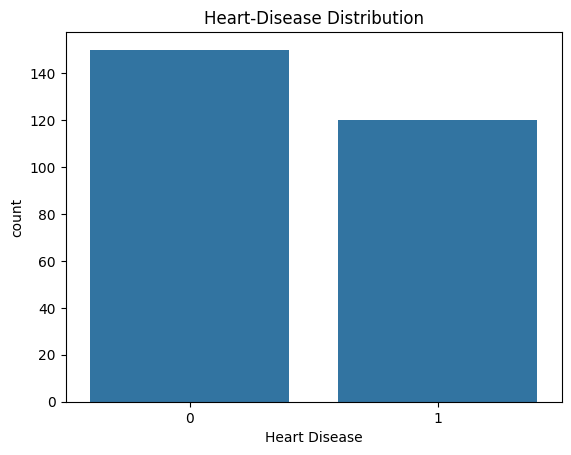

In [ ]:
sns.countplot(x="Heart Disease", data=data)
plt.title("Heart-Disease Distribution")
plt.show()

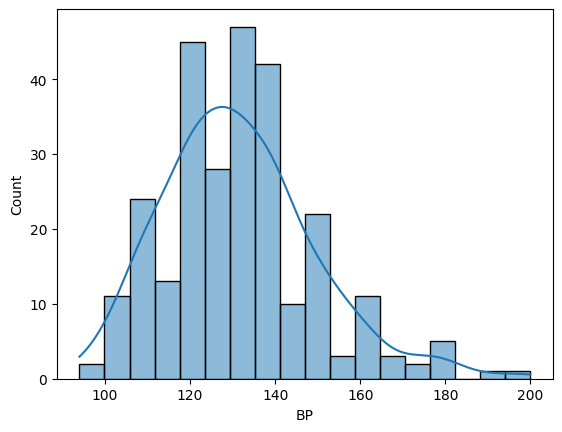

In [ ]:
sns.histplot(data['BP'], kde=True)
plt.show()

Separet Features and Target


1.   "X" is all input variables
2.   "Y" is prediction target (0 or 1)



In [ ]:
#Step 6: Define Features and Target
X = data.drop('Heart-Disease', axis=1)
y = data['Heart-Disease']

**Question 1: Understanding the Dataset**

Interpretation: The dataset contains 270 patient records and 15 columns. The columns include demographic, clinical, and heart-related information. There are no duplicate records. I will check the missing-value results before proceeding to data preprocessing.


Separet Features and Target


1.   "X" is all input variables
2.   "Y" is prediction target (0 or 1)



In [ ]:
# Steo 6: Define input features (X)
X = data.drop('Heart-Disease', axis=1)

# Define target variable (Y)

Y = data['Heart-Disease']

In [ ]:
#Step 7: Identify Categorical and Numerical Columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['Sex'], dtype='object')

Numerical Columns:
Index(['ID', 'Age', 'Chest-pain-type', 'BP', 'Cholesterol', 'FBS-over-120',
       'EKG-results', 'Max-HR', 'Exercise-angina', 'ST-depression',
       'Slope-of-ST', 'Number-of-vessels-fluro', 'Thallium'],
      dtype='object')


In [ ]:
#Step: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Step 8: Data Preprocessing
#- Handle missing values
#- Encode categorical variables
#- Scale numerical features
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in y_train:")
print(y_train.isnull().sum())

Missing values in X_train:
ID                         213
Age                          0
Sex                          0
Chest-pain-type              0
BP                           0
Cholesterol                  0
FBS-over-120                 0
EKG-results                  0
Max-HR                       0
Exercise-angina              0
ST-depression                0
Slope-of-ST                  0
Number-of-vessels-fluro      0
Thallium                     0
dtype: int64

Missing values in y_train:
0


In [ ]:
print("Numerical Pipeline:")
print(num_pipeline)

print("\nCategorical Pipeline:")
print(cat_pipeline)

print("\nCombined Preprocessor:")
print(preprocessor)

Numerical Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

Categorical Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

Combined Preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['ID', 'Age', 'Chest-pain-type', 'BP', 'Cholesterol', 'FBS-over-120',
       'EKG-results', 'Max-HR', 'Exercise-angina', 'ST-depression',
       'Slope-of-ST', 'Number-of-vessels-fluro', 'Thallium'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  Si

In [ ]:
print("Numerical columns:", list(numerical_cols))
print("Categorical columns:", list(categorical_cols))

Numerical columns: ['ID', 'Age', 'Chest-pain-type', 'BP', 'Cholesterol', 'FBS-over-120', 'EKG-results', 'Max-HR', 'Exercise-angina', 'ST-depression', 'Slope-of-ST', 'Number-of-vessels-fluro', 'Thallium']
Categorical columns: ['Sex']


In [ ]:
#Step 9: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Step 10: Define Machine Learning Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}


Model: Logistic Regression
Accuracy: 0.9074074074074074
              precision    recall  f1-score   support

     Absence       0.91      0.94      0.93        33
    Presence       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



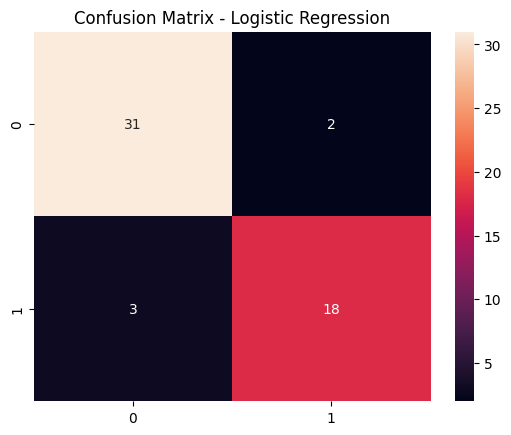


Model: Decision Tree
Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

     Absence       0.82      0.70      0.75        33
    Presence       0.62      0.76      0.68        21

    accuracy                           0.72        54
   macro avg       0.72      0.73      0.72        54
weighted avg       0.74      0.72      0.73        54



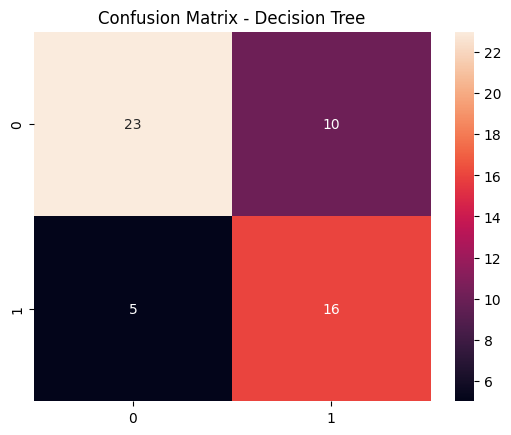


Model: Random Forest
Accuracy: 0.8703703703703703
              precision    recall  f1-score   support

     Absence       0.84      0.97      0.90        33
    Presence       0.94      0.71      0.81        21

    accuracy                           0.87        54
   macro avg       0.89      0.84      0.86        54
weighted avg       0.88      0.87      0.87        54



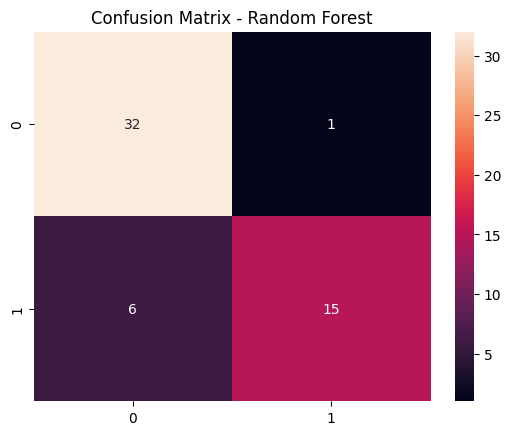

In [ ]:
#Step 11: Train and Evaluate Models
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\nModel: {name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    results.append((name, acc))

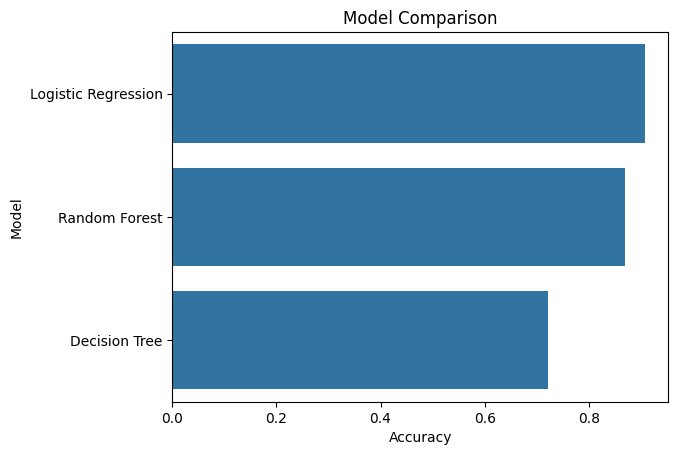

In [ ]:
#Step 12: Compare Models
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df
sns.barplot(x="Accuracy", y="Model", data=results_df)
plt.title("Model Comparison")
plt.show()

In [ ]:
# Predict on test data
y_pred = pipeline.predict(X_test)

print("Predictions on test data:")
print(y_pred[:10])   # first 10 predictions

print("\nActual values:")
print(y_test[:10].values)   # first 10 real values

Predictions on test data:
['Absence' 'Presence' 'Absence' 'Absence' 'Absence' 'Presence' 'Absence'
 'Absence' 'Absence' 'Absence']

Actual values:
['Presence' 'Presence' 'Absence' 'Absence' 'Absence' 'Presence' 'Absence'
 'Absence' 'Absence' 'Absence']


In [ ]:
results_compare = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results_compare.head(10))

     Actual Predicted
0  Presence   Absence
1  Presence  Presence
2   Absence   Absence
3   Absence   Absence
4   Absence   Absence
5  Presence  Presence
6   Absence   Absence
7   Absence   Absence
8   Absence   Absence
9   Absence   Absence


In [ ]:
new_data = pd.DataFrame([{
    'ID': 1,
    'Age': 60,
    'Sex': 'Male',
    'Chest-pain-type': 4,
    'BP': 140,
    'Cholesterol': 293,
    'FBS-over-120': 0,
    'EKG-results': 2,
    'Max-HR': 170,
    'Exercise-angina': 0,
    'ST-depression': 1.2,
    'Slope-of-ST': 2,
    'Number-of-vessels-fluro': 2,
    'Thallium': 7
}])

user_prediction = pipeline.predict(new_data)
print("Prediction for new user input:", user_prediction[0])

Prediction for new user input: Presence


In [ ]:
user_prediction_proba = pipeline.predict_proba(new_data)

print("Prediction probabilities:", user_prediction_proba)

Prediction probabilities: [[0.06 0.94]]
